## 4c Training final model:
- numerics only
- 'Unknown' subsumed into 'closest' category
- use df_model_integrate_unknown.csv and drop smart features

In [1]:
import pandas as pd
import seaborn as sns

In [20]:
df_BI = pd.read_csv("df_model_integrate_unknown.csv")
df_BI.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875 entries, 0 to 874
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Trip_Distance_km        875 non-null    float64
 1   Passenger_Count         875 non-null    float64
 2   Base_Fare               875 non-null    float64
 3   Per_Km_Rate             875 non-null    float64
 4   Per_Minute_Rate         875 non-null    float64
 5   Trip_Duration_Minutes   875 non-null    float64
 6   Trip_Price              875 non-null    float64
 7   IsBusinessHour          875 non-null    int64  
 8   IsRain                  875 non-null    int64  
 9   IsSnow                  875 non-null    int64  
 10  IsWeekend               875 non-null    int64  
 11  Traffic_Conditions_Num  875 non-null    int64  
 12  Time_of_Day_Num         875 non-null    int64  
dtypes: float64(7), int64(6)
memory usage: 89.0 KB


In [21]:
df_model = df_BI.drop(columns=["IsBusinessHour", "IsRain", "IsSnow", "IsWeekend","Traffic_Conditions_Num", "Time_of_Day_Num"])
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875 entries, 0 to 874
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       875 non-null    float64
 1   Passenger_Count        875 non-null    float64
 2   Base_Fare              875 non-null    float64
 3   Per_Km_Rate            875 non-null    float64
 4   Per_Minute_Rate        875 non-null    float64
 5   Trip_Duration_Minutes  875 non-null    float64
 6   Trip_Price             875 non-null    float64
dtypes: float64(7)
memory usage: 48.0 KB


In [22]:
df_model[:20]

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,3.0,3.560000,0.800000,0.320000,53.82,36.2624
1,36.87,1.0,2.700000,1.210000,0.150000,37.27,52.9032
2,30.33,4.0,3.480000,0.510000,0.150000,116.81,36.4698
3,8.64,2.0,2.550000,1.710000,0.480000,89.33,60.2028
4,3.85,4.0,3.510000,1.660000,0.292647,5.05,11.2645
5,43.44,3.0,2.970000,1.870000,0.230000,61.96,101.1216
6,35.70,2.0,3.390000,1.520000,0.470000,61.96,75.5657
7,41.79,3.0,4.600000,1.770000,0.110000,86.95,88.1328
8,11.40,3.0,4.120000,1.236359,0.150000,84.12,36.1180
9,9.91,2.0,2.320000,1.260000,0.340000,41.72,28.9914


### split

In [7]:
# split
# Features / target
X, y = df_model.drop(columns=["Trip_Price"]), df_model["Trip_Price"].astype(float)

In [16]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [10]:
# train/test on 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# train RF
rf = RandomForestRegressor(
    n_estimators=400, 
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

,n_estimators,400
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
# predict on deep forest RF
pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)
print({"mae": mae, "rmse": rmse, "r2": r2})

{'mae': 4.799463198571428, 'rmse': 6.7840680136330755, 'r2': 0.9235578144671365}


In [13]:
# deep forest MAPE
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, pred)
print("MAPE:", round(mape*100, 2), "%")

MAPE: 10.4 %


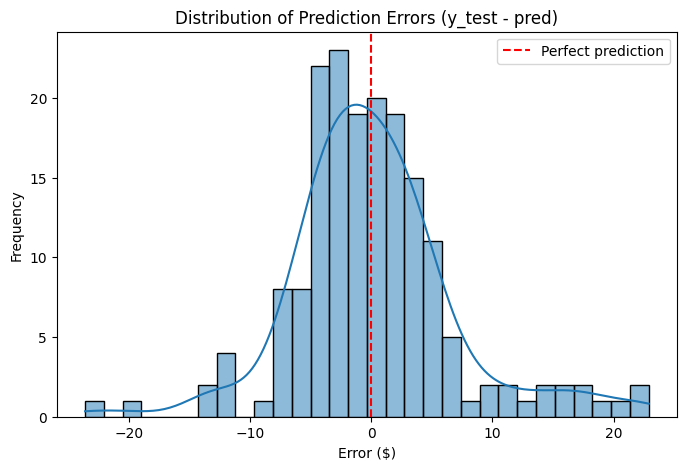

In [14]:
# histogram of error distribution
import matplotlib.pyplot as plt

errors = y_test - pred   # positive = model underpredicted, negative = overpredicted

plt.figure(figsize=(8,5))
sns.histplot(errors, bins=30, kde=True)
plt.axvline(0, color="red", linestyle="--", label="Perfect prediction")
plt.title("Distribution of Prediction Errors (y_test - pred)")
plt.xlabel("Error ($)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

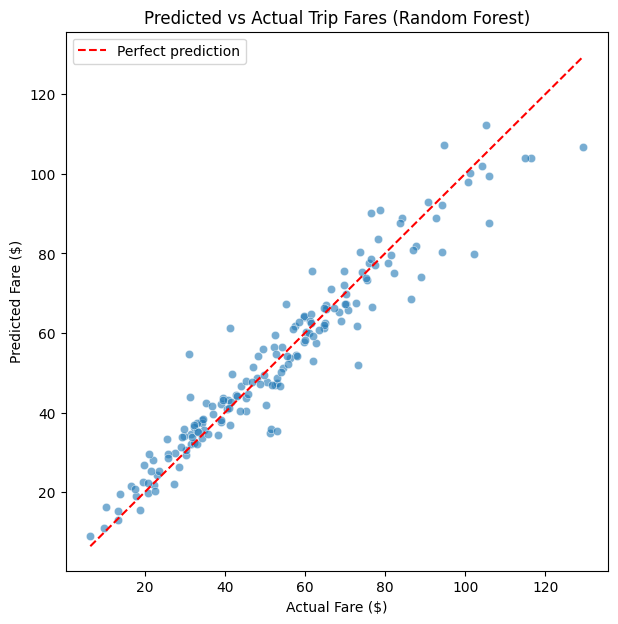

In [15]:
# scatterplot
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color="red", linestyle="--", label="Perfect prediction")

plt.xlabel("Actual Fare ($)")
plt.ylabel("Predicted Fare ($)")
plt.title("Predicted vs Actual Trip Fares (Random Forest)")
plt.legend()
plt.show()

In [18]:
from sklearn.inspection import permutation_importance

# permutation importance = test which feature has most importance on predicting model performance
result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)
imp_perm = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)
print(imp_perm.head(10))

Trip_Distance_km         1.180539
Per_Km_Rate              0.453313
Trip_Duration_Minutes    0.281796
Per_Minute_Rate          0.163808
Passenger_Count          0.001471
Base_Fare               -0.000046
dtype: float64


In [ ]:
# export trained model


### BI sandbox to test hypothesis of uplift combos

In [19]:
# quick BI sandbox to check df_model against BI uplifts using groupby

baseline = df_model["Trip_Price"].mean()
baseline

np.float64(52.29525645714286)

In [45]:
rain_avg = df_BI[df_BI["IsRain"] == 1]["Trip_Price"].mean()
uplift_percent = ((rain_avg - baseline) / baseline) * 100

print(baseline)
print(rain_avg)
print(uplift_percent)

52.29525645714286
53.13848884297521
1.6124452636031954


In [25]:
business_avg = df_BI[df_BI["IsBusinessHour"] == 1]["Trip_Price"].mean()
uplift_bsh = ((business_avg - baseline)/ baseline) * 100

print(baseline)
print(business_avg)
print(uplift_bsh)

52.29525645714286
52.550567816091956
0.48821131445894483


In [46]:
# Group by combinations of smart features
combos = (
    df_BI
    .groupby(["IsRain", "IsSnow", "IsWeekend", "IsBusinessHour", "Traffic_Conditions_Num", "Time_of_Day_Num"])
    ["Trip_Price"]
    .mean()
    .reset_index()
)

# Add uplift compared to baseline
baseline = df_model["Trip_Price"].mean()
combos["uplift_pct"] = ((combos["Trip_Price"] - baseline) / baseline) * 100

# Sort by biggest uplift
leaderboard = combos.sort_values(by="uplift_pct", ascending=False)
leaderboard = leaderboard.reset_index(drop=True)

print(leaderboard.head(10))

   IsRain  IsSnow  IsWeekend  IsBusinessHour  Traffic_Conditions_Num  \
0       0       1          0               0                       1   
1       1       0          1               0                       2   
2       0       0          1               0                       2   
3       1       0          1               0                       2   
4       1       0          1               0                       1   
5       0       1          0               0                       2   
6       0       0          0               0                       2   
7       0       1          0               0                       0   
8       1       0          1               0                       1   
9       0       1          1               0                       2   

   Time_of_Day_Num  Trip_Price  uplift_pct  
0                1   79.292880   51.625377  
1                0   77.196300   47.616257  
2                0   72.105340   37.881225  
3                3   70.788

In [40]:
# test which combos recur the most times resulting in highest uplft fares:
# tweak the above with .agg function

combos = (
    df_BI
    .groupby(["IsRain", "IsBusinessHour", "IsSnow", "IsWeekend", "Traffic_Conditions_Num", "Time_of_Day_Num"])
    .agg(
        avg_fare=("Trip_Price", "mean"),
        trip_count=("Trip_Price", "size")
    )
    .reset_index()
)

# Baseline from clean model dataset
baseline = df_model["Trip_Price"].mean()

# Add uplift %
combos["uplift_pct"] = ((combos["avg_fare"] - baseline) / baseline) * 100

# Sort leaderboard by uplift
leaderboard = combos.sort_values(by="uplift_pct", ascending=False).reset_index(drop=True)

print(leaderboard.head(12))


    IsRain  IsBusinessHour  IsSnow  IsWeekend  Traffic_Conditions_Num  \
0        0               0       1          0                       1   
1        1               0       0          1                       2   
2        0               0       0          1                       2   
3        1               0       0          1                       2   
4        1               0       0          1                       1   
5        0               0       1          0                       2   
6        0               0       0          0                       2   
7        0               0       1          0                       0   
8        1               0       0          1                       1   
9        0               0       1          1                       2   
10       0               0       1          0                       1   
11       1               0       0          0                       1   

    Time_of_Day_Num   avg_fare  trip_count  uplift

In [41]:
# sorted by highest trip_count to find reliable opportunities
# data shows that highest trip_count does not neccessarily give highest uplift
# combination

leaderboard_by_count = leaderboard.sort_values(by="trip_count", ascending=False).reset_index(drop=True)

print(leaderboard_by_count.head(12))

    IsRain  IsBusinessHour  IsSnow  IsWeekend  Traffic_Conditions_Num  \
0        0               1       0          0                       1   
1        0               1       0          0                       0   
2        0               1       0          0                       1   
3        0               1       0          0                       0   
4        0               1       0          0                       2   
5        0               0       0          0                       1   
6        0               1       0          0                       2   
7        0               0       0          0                       0   
8        0               0       0          1                       1   
9        0               0       0          0                       0   
10       1               0       0          0                       0   
11       1               0       0          0                       0   

    Time_of_Day_Num   avg_fare  trip_count  uplift

In [42]:
# filter out any negative uplift and also any under 5%
# Keep only positive uplifts >= 5%
# sort by highest uplift
leaderboard_filtered = leaderboard[
    (leaderboard["uplift_pct"] >= 5) & (leaderboard["trip_count"] >= 5)
].reset_index(drop=True)

print(leaderboard_filtered.head(10))

   IsRain  IsBusinessHour  IsSnow  IsWeekend  Traffic_Conditions_Num  \
0       0               0       1          0                       1   
1       0               0       0          1                       2   
2       1               0       0          1                       2   
3       1               0       0          1                       1   
4       0               0       0          0                       2   
5       0               0       1          0                       0   
6       1               0       0          1                       1   
7       1               0       0          0                       1   
8       0               0       0          1                       2   
9       0               0       0          1                       0   

   Time_of_Day_Num   avg_fare  trip_count  uplift_pct  
0                1  79.292880           5   51.625377  
1                0  72.105340           5   37.881225  
2                3  70.788640          

In [44]:
# filter by highest trip_count x uplift
# Opportunity score = trip_count x uplift_pct
leaderboard_filtered["opportunity_score"] = (
    leaderboard_filtered["trip_count"] * leaderboard_filtered["uplift_pct"]
)

# Sort by score
leaderboard_ranked = leaderboard_filtered.sort_values(
    by="opportunity_score", ascending=False
).reset_index(drop=True)

print(leaderboard_ranked.head(10))

   IsRain  IsBusinessHour  IsSnow  IsWeekend  Traffic_Conditions_Num  \
0       0               0       0          0                       2   
1       0               1       0          0                       0   
2       1               0       0          1                       1   
3       0               0       0          1                       0   
4       0               0       1          0                       1   
5       1               0       0          1                       1   
6       0               0       0          0                       0   
7       0               0       0          1                       2   
8       0               0       1          0                       0   
9       1               0       0          1                       2   

   Time_of_Day_Num   avg_fare  trip_count  uplift_pct  opportunity_score  
0                2  66.407740          25   26.986164         674.654094  
1                0  56.401459          41    7.851959    